# Chronos-2 Benchmarking

| | |
|---|---|
| **Organization** | Amazon Web Services (AWS) |
| **Version** | Chronos-2 (October 2025) |
| **Parameters** | 120M |
| **Input Features** | Target series, optional covariates (past and future known) |

## Key Characteristics

Chronos-2 introduces support for multivariate and covariate-informed forecasting within a single architecture. The model employs a group attention mechanism that alternates between time attention (aggregating information across patches within a single series) and group attention (aggregating information across all series within a group at each patch index). This design enables in-context learning across related series and covariates without requiring task-specific fine-tuning.

The model was trained on a combination of real-world datasets (GiftEvalPretrain) and large-scale synthetic data generated through multivariate structure imposition on univariate base series.

---

**Validation split:** Train on periods 1–36, validate on 37–42 (identical to Notebook 6)  
**Target:** `Revenue cons. (anon)` at subsegment level  
**Runtime:** T4 GPU (Google Colab) — set manually: Runtime → Change runtime type → T4 GPU


---
## 1. Dependencies


In [63]:
# ── Install ──
!pip install -q "chronos-forecasting>=2.0"


In [64]:
# ── Imports ──
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')


GPU available: True
Device: Tesla T4


---
## 2. Configuration


In [65]:
# ── Constants ──
PERIOD_COL = 'Anon Period'
TARGET     = 'Revenue cons. (anon)'
SUBSEG_COL = 'TGL Business Subsegment'
VAL_CUTOFF = 36
HORIZON    = 6

# ── Paths ──
DATA_PATH = '/content/drive/MyDrive/Coding/data/features/training_subsegment_fs.parquet'
VAL_PATH  = '/content/drive/MyDrive/Coding/data/features/validation_subsegment_fs.parquet'
OUTPUT_DIR = Path('/content/drive/MyDrive/Coding/data/predictions/')


---
## 3. Data & Function Loading


In [66]:
import sys
from google.colab import drive

drive.mount('/content/drive')

sys.path.insert(0, '/content/drive/MyDrive/Coding/functions/')
from pipeline_functions import *


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
# ── Load training data & split ──
full_train = pd.read_parquet(DATA_PATH)
train_df   = full_train[full_train[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df     = full_train[full_train[PERIOD_COL] >  VAL_CUTOFF].copy()

print(f'Full train:      {full_train.shape}')
print(f'Train (1–36):    {train_df.shape}')
print(f'Val   (37–42):   {val_df.shape}')


Full train:      (4237, 110)
Train (1–36):    (3524, 110)
Val   (37–42):   (713, 110)


In [68]:
# ── Feature engineering: build clean feature list & subsegment list ──
exclude = [TARGET, PERIOD_COL, SUBSEG_COL,
           'TGL Biz Desc', 'TGL Business Unit',
           'TGL Business Segment', 'Orders cons. (anon)']
           
feature_cols = [c for c in full_train.columns if c not in exclude]
feature_cols = filter_leaky_features(feature_cols, orders_strategy='drop')

subsegments = sorted(
    train_df.dropna(subset=[TARGET])
    .groupby(SUBSEG_COL, observed=True)
    .size()
    .pipe(lambda s: s[s >= 1].index)
    .tolist()
)

print(f'Feature cols after leaky filter: {len(feature_cols)}')
print(f'Subsegments:                     {len(subsegments)}')

Feature cols after leaky filter: 53
Subsegments:                     119


---
## 4. Model Loading


In [69]:
from chronos import Chronos2Pipeline

chronos2_pipeline = Chronos2Pipeline.from_pretrained(
    'amazon/chronos-2',
    device_map='cuda' if torch.cuda.is_available() else 'cpu'
)
print('Chronos-2 loaded.')


Chronos-2 loaded.


---
## 5. Validation Forecasting (Periods 37–42)


In [70]:
# ── Build validation contexts ──
val_contexts, val_skipped = [], []

for seg in subsegments:
    train_s = train_df[train_df[SUBSEG_COL] == seg].sort_values(PERIOD_COL).dropna(subset=[TARGET])
    val_s   = val_df[val_df[SUBSEG_COL] == seg].sort_values(PERIOD_COL).dropna(subset=[TARGET])
    if len(train_s) < 3 or len(val_s) == 0:
        val_skipped.append(seg)
        continue
    val_contexts.append(build_context(train_s, seg, VAL_CUTOFF, TARGET, PERIOD_COL, feature_cols))

val_batch_df = pd.concat(val_contexts, ignore_index=True)
print(f'Contexts built: {len(val_contexts)} | Skipped: {len(val_skipped)}')
if val_skipped:
    print('Skipped:', val_skipped)

Contexts built: 107 | Skipped: 12
Skipped: ['SSI02710', 'SSI0278604', 'SSI0278624', 'SSI0278630', 'SSI02796', 'SSI02798', 'SSI02799', 'SSI03782', 'SSI04783', 'SSI0478499', 'SSI07098', 'SSI07099']


In [71]:
# ── Batch predict — validation (single GPU call) ──
val_pred_df = chronos2_pipeline.predict_df(
    val_batch_df,
    prediction_length=HORIZON,
    quantile_levels=[0.5],
    id_column='id',
    timestamp_column='timestamp',
    target='target',
)
chronos2_results = {
    seg: grp['0.5'].values
    for seg, grp in val_pred_df.groupby('id')
}
print(f'Results: {len(chronos2_results)}/{len(subsegments)}')

Results: 107/119


In [72]:
evaluate(chronos2_results, 'Chronos-2', val_df, SUBSEG_COL, PERIOD_COL, TARGET)


Chronos-2 — RMSE: 8,349,692 | wMAPE: 9.9% | R²: 0.9850


{'Model': 'Chronos-2',
 'RMSE': np.float64(8349692.45154503),
 'wMAPE': np.float64(9.917142264188127),
 'R2': 0.9850382122656587}

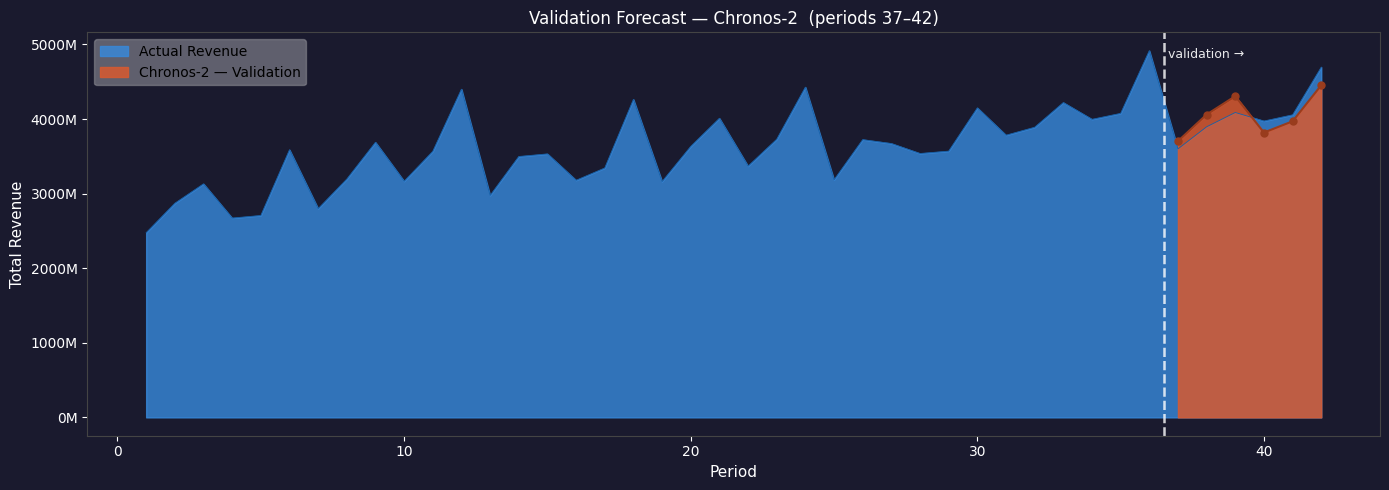

In [73]:
# ── Aggregate predictions by period & plot ──
agg_preds = {}
for t in range(HORIZON):
    period = VAL_CUTOFF + 1 + t   # 37 … 42
    agg_preds[period] = sum(
        preds[t] for preds in chronos2_results.values() if len(preds) > t
    )

plot_forecast_area(full_train, agg_preds, 'Chronos-2', TARGET, PERIOD_COL)

---
## 6. Blind Forecast (Periods 43–48)


In [74]:
# ── Load hold-out feature set ──
val_blind = pd.read_parquet(VAL_PATH)

# Apply same leaky-feature filter as full_train
val_feature_cols = filter_leaky_features(
    [c for c in val_blind.columns if c not in exclude],
    orders_strategy='drop'
)
assert set(val_feature_cols) == set(feature_cols), \
    f'Feature mismatch: train={len(feature_cols)}, val={len(val_feature_cols)}'

print(f'Hold-out set: {val_blind.shape}')
print(f'Feature cols after leaky filter: {len(val_feature_cols)}')

TEST_CUTOFF = full_train[PERIOD_COL].max()  # = 42
test_subsegments = sorted(val_blind[SUBSEG_COL].unique())
print(f'Subsegments to forecast: {len(test_subsegments)} | Test cutoff: {TEST_CUTOFF}')


Hold-out set: (715, 110)
Feature cols after leaky filter: 53
Subsegments to forecast: 124 | Test cutoff: 42


In [75]:
# ── Build test contexts ──
USE_FUTURE_COVARIATES = False  # set to True to include val_blind features as future context
test_contexts, test_skipped = [], []

for seg in test_subsegments:
    train_s = full_train[full_train[SUBSEG_COL] == seg].sort_values(PERIOD_COL).dropna(subset=[TARGET])
    val_s   = val_blind[val_blind[SUBSEG_COL] == seg].sort_values(PERIOD_COL)
    if len(train_s) < 3:
        test_skipped.append(seg)
        continue
    hist = build_context(train_s, seg, TEST_CUTOFF, TARGET, PERIOD_COL, feature_cols)
    
    if USE_FUTURE_COVARIATES and len(val_s) == HORIZON:                                                         
        fut = val_s[val_feature_cols].copy()                                                                    
        fut['timestamp'] = val_s[PERIOD_COL].apply(period_to_ts).values                                         
        fut['target'] = float('nan')                                                                            
        fut['id'] = seg                                                                                         
        ctx = pd.concat([hist, fut[hist.columns]], ignore_index=True)                                           
    else:
      ctx = hist  

    test_contexts.append(ctx)

test_batch_df = pd.concat(test_contexts, ignore_index=True)
print(f'Contexts built: {len(test_contexts)} | Skipped: {len(test_skipped)}')
if test_skipped:
    print('Skipped:', test_skipped)

Contexts built: 122 | Skipped: 2
Skipped: ['SSI0278218', 'SSI0278468']


In [76]:
# ── Batch predict — test (single GPU call) ──
test_pred_df = chronos2_pipeline.predict_df(
    test_batch_df,
    prediction_length=HORIZON,
    quantile_levels=[0.5],
    id_column='id',
    timestamp_column='timestamp',
    target='target',
)
chronos2_test_results = {
    seg: grp['0.5'].values
    for seg, grp in test_pred_df.groupby('id')
}
print(f'Results: {len(chronos2_test_results)} | Skipped: {len(test_skipped)}')

Results: 122 | Skipped: 2


In [77]:
# ── Build submission DataFrame ──
rows = [
    {SUBSEG_COL: seg, PERIOD_COL: TEST_CUTOFF + 1 + t, 'Revenue_Predicted': float(p)}
    for seg, preds in chronos2_test_results.items()
    for t, p in enumerate(preds)
]
submission_df = (
    pd.DataFrame(rows)
    .merge(val_blind[[SUBSEG_COL, PERIOD_COL]], on=[SUBSEG_COL, PERIOD_COL], how='inner')
    .reset_index(drop=True)
)
print(f'Submission rows: {len(submission_df)}')  # sollte 715 sein
submission_df

Submission rows: 711


,TGL Business Subsegment,Anon Period,Revenue_Predicted
0,SSI02710,44,2.521906e+03
1,SSI02710,45,2.711043e+03
2,SSI02710,48,1.858648e+03
3,SSI0271002,43,1.349763e+06
4,SSI0271002,44,1.252570e+06
...,...,...,...
706,SSI0708310,44,7.804432e+06
707,SSI0708310,45,7.914231e+06
708,SSI0708310,46,7.507940e+06
709,SSI0708310,47,8.114929e+06


SSI0278218 appears 3× in the validation set but not in the training set.  
SSI0278468 appears 1× in the validation set but not in the training set.

Both IDs are therefore excluded from the final prediction.

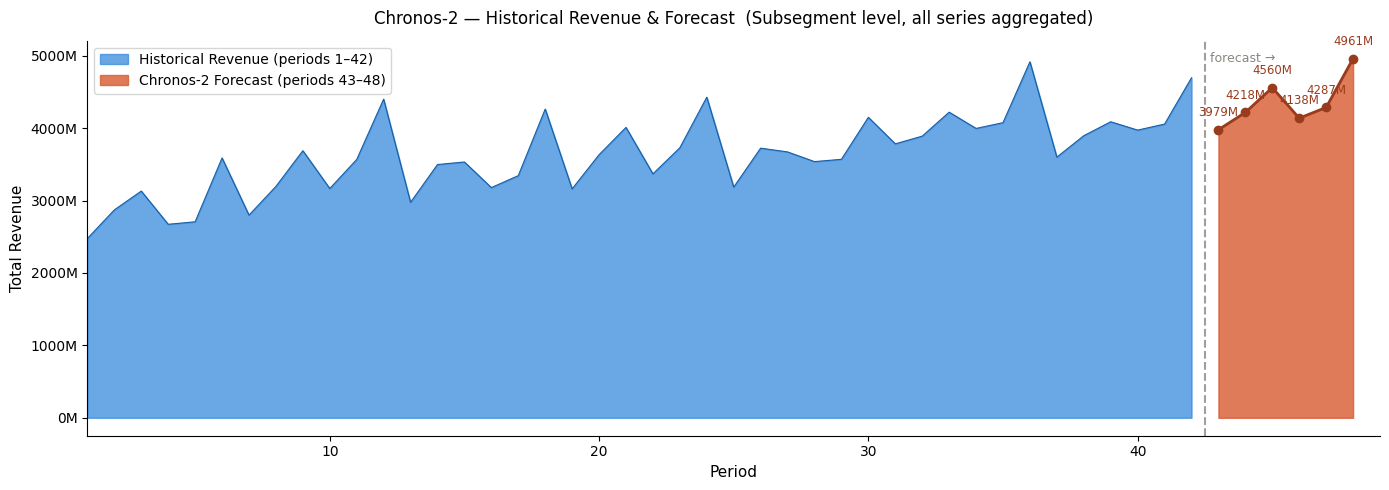

PosixPath('/content/drive/MyDrive/Coding/data/predictions/forecast_plot_chronos-2.png')

In [78]:
from src.code.functions_models import plot_forecast_comparison

# ── Plot blind forecast ──
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plot_forecast_comparison(
    train_df=full_train,
    submission_df=submission_df,
    period_col=PERIOD_COL,
    target_col=TARGET,
    best_model_name='Chronos-2',
    output_dir=OUTPUT_DIR,
)
